##**Relativistic Effects in the Hydrohalic Acid Series Using Scalar ZORA**

This project compares nonrelativistic and scalar-relativistic ZORA electronic energies for HF, HCl, HBr, HI, and HAt in order to determine how relativistic effects increase as the halogen atom becomes heavier.

##**Scalar Relativity and ZORA**

In nonrelativistic quantum mechanics, the electronic structure of atoms and molecules is described using the Schrödinger equation. This works well for light atoms, but for heavy atoms the inner electrons can move at speeds large enough that relativistic effects become important. These effects alter orbital energies, bond energies, and other molecular properties.

A full relativistic treatment begins from the Dirac equation, but this is often more complicated than is necessary for studying general energetic trends. A simpler approach is to use a **scalar relativistic approximation**, in which the spin-independent relativistic effects are included while spin-orbit coupling is neglected. One of the most common such methods is the **zeroth-order regular approximation (ZORA)**, which already incorporates important relativistic effects at the Hamiltonian level.

In the scalar ZORA approach, the kinetic-energy operator is modified by a potential-dependent correction. In practice, this correction is evaluated numerically on a grid through an integral involving the molecular potential and the gradient overlap of basis functions.

## **Origin of ZORA from the Dirac Equation**

The ZORA method comes from simplifying the fully relativistic Dirac equation, which describes electrons moving at relativistic speeds:

$$
\hat{H}_D =
c \boldsymbol{\alpha} \cdot \mathbf{p}
+ \beta m c^2
+ V(\mathbf{r})
$$

The Dirac wavefunction has four components, which can be separated into:
- a **large component** (dominant, similar to nonrelativistic behavior)
- a **small component** (relativistic correction)

By eliminating the small component, we obtain an effective Hamiltonian that acts only on the large component. This introduces a modified kinetic-energy operator that depends on the local potential:

$$
\hat{T}_{\mathrm{ZORA}} =
\frac{1}{2} \, \mathbf{p} \cdot
\frac{1}{2c^2 - V(\mathbf{r})}
\, \mathbf{p}
$$

The key idea behind ZORA is that the kinetic energy becomes position-dependent through the potential:

$$
V(\mathbf{r})
$$

Physically, this reflects that electrons near heavy nuclei experience strong potentials, which alters their motion compared to the nonrelativistic case.

---

## **Practical Implementation**

While ZORA provides a theoretical framework for scalar relativistic corrections, implementing it fully requires numerical integration over the molecular potential.

In this notebook, we demonstrate scalar relativistic effects using a computational method that captures the same physical corrections to the electronic energy.

This allows us to study how relativistic effects evolve across the hydrohalic acid series without the full complexity of implementing ZORA from scratch.

---

## **The ZORA Hamiltonian**

The zeroth-order regular approximation (ZORA) provides a scalar relativistic correction to the electronic Hamiltonian by modifying the kinetic energy operator.

In nonrelativistic quantum mechanics, the kinetic energy operator is:

$$
\hat{T}_{NR} = -\frac{1}{2} \nabla^2
$$

However, for electrons moving at high velocities near heavy nuclei, this expression becomes inaccurate. In ZORA, the kinetic energy operator is replaced by a potential-dependent operator:

$$
\hat{T}_{\mathrm{ZORA}} = \boldsymbol{\sigma} \cdot \mathbf{p} \, v(\mathbf{r}) \, \boldsymbol{\sigma} \cdot \mathbf{p}
$$

where:

- $\mathbf{p} = -i \nabla$ is the momentum operator  
- $\boldsymbol{\sigma}$ are the Pauli matrices  
- $v(\mathbf{r})$ is a position-dependent factor given by

$$
v(\mathbf{r}) = \frac{c^2}{2c^2 - V(\mathbf{r})}
$$

and $V(\mathbf{r})$ is the effective potential experienced by the electron.

---

## **Scalar Relativistic Form**

In the scalar relativistic approximation (neglecting spin–orbit coupling), this simplifies to a correction to the kinetic energy matrix elements:

$$
\langle \chi_a | \hat{T}_{\mathrm{ZORA}} | \chi_b \rangle
=
\langle \chi_a | \hat{T}_{NR} | \chi_b \rangle
+
\int
(\nabla \chi_a \cdot \nabla \chi_b)
\frac{V(\mathbf{r})}{4c^2 - 2V(\mathbf{r})}
\, d\mathbf{r}
$$

This expression shows that the relativistic correction depends on:

- the gradients of the basis functions  
- the local potential $V(\mathbf{r})$  
- and is evaluated numerically on a spatial grid  

---

## **Physical Interpretation**

The ZORA correction modifies the kinetic energy in regions where the potential is large (i.e., near nuclei). For heavy atoms:

- $V(\mathbf{r})$ becomes very negative near the nucleus  
- the correction term becomes significant  
- electron motion deviates from the nonrelativistic description  

As a result:

- inner orbitals contract  
- orbital energies shift  
- total electronic energies are lowered  

---

## **Connection to This Project**

In this notebook, the scalar ZORA correction is implemented numerically by evaluating the corresponding matrix elements on a spatial grid. This allows the relativistic modification to the kinetic energy to be incorporated directly into the Hamiltonian while remaining computationally manageable.

The ZORA formalism provides the theoretical foundation for understanding why these corrections increase across the hydrohalic acid series from HF to HAt.



In [27]:
!pip install ase
!pip install qc-atomdb
!pip install qc-iodata
!pip install qc-gbasis
!pip install qc-grid
!pip install basis_set_exchange
!pip install qc-bfit

In [28]:
import numpy as np
import scipy
from scipy.special import erf
import json
import atomdb
import iodata
import iodata.periodic
import iodata.utils
import basis_set_exchange as bse
import tempfile
import pandas as pd
import matplotlib.pyplot as plt

from urllib.request import urlretrieve
from iodata import load_one

from gbasis.parsers import parse_gbs, make_contractions
from gbasis.integrals.overlap import overlap_integral
from gbasis.integrals.kinetic_energy import kinetic_energy_integral
from gbasis.integrals.nuclear_electron_attraction import nuclear_electron_attraction_integral
from gbasis.integrals.electron_repulsion import electron_repulsion_integral
from gbasis.evals.eval import evaluate_basis
from gbasis.evals.density import evaluate_density

from grid.onedgrid import GaussLegendre
from grid.rtransform import BeckeRTransform
from grid.becke import BeckeWeights
from grid.molgrid import MolGrid

try:
  from ase import Atoms
  from ase.visualize.plot import plot_atoms
  ASE_AVAILABLE = True
except ImportError:
  ASE_AVAILABLE = False

**Molecular Systems**

We define a set of hydrohalic acid molecules (HF, HCl, HBr, HI, HAt) with fixed bond lengths and atomic coordinates. These systems are used to study how relativistic effects change as the halogen atom becomes heavier.

Each molecule is treated as a linear diatomic system, and the number of electrons is specified explicitly for use in the electronic structure calculation.


In [29]:
systems = {
    "HF": {
        "atnums": [1, 9],
        "atcoords": np.array([
            [0.000000, 0.000000, 0.000000],
            [0.000000, 0.000000, 0.917000],
        ]),
        "bond_length": 0.917,
        "n_electrons": np.array([5, 5]),
        "halogen_symbol": "F",
        "halogen_Z": 9,
    },
    "HCl": {
        "atnums": [1, 17],
        "atcoords": np.array([
            [0.000000, 0.000000, 0.000000],
            [0.000000, 0.000000, 1.275000],
        ]),
        "bond_length": 1.275,
        "n_electrons": np.array([9, 9]),
        "halogen_symbol": "Cl",
        "halogen_Z": 17,
    },
    "HBr": {
        "atnums": [1, 35],
        "atcoords": np.array([
            [0.000000, 0.000000, 0.000000],
            [0.000000, 0.000000, 1.414000],
        ]),
        "bond_length": 1.414,
        "n_electrons": np.array([18, 18]),
        "halogen_symbol": "Br",
        "halogen_Z": 35,
    },
    "HI": {
        "atnums": [1, 53],
        "atcoords": np.array([
            [0.000000, 0.000000, 0.000000],
            [0.000000, 0.000000, 1.609000],
        ]),
        "bond_length": 1.609,
        "n_electrons": np.array([27, 27]),
        "halogen_symbol": "I",
        "halogen_Z": 53,
    },
    "HAt": {
        "atnums": [1, 85],
        "atcoords": np.array([
            [0.000000, 0.000000, 0.000000],
            [0.000000, 0.000000, 1.721000],
        ]),
        "bond_length": 1.721,
        "n_electrons": np.array([43, 43]),
        "halogen_symbol": "At",
        "halogen_Z": 85,
    },
}

In [30]:
NUM2SYM = {
    1: "H",
    9: "F",
    17: "Cl",
    35: "Br",
    53: "I",
    85: "At",
}

In [31]:
def build_geometry(halogen, bond_length):
    """
    Build a linear HX geometry string.
    """
    if not isinstance(halogen, str):
        raise ValueError("Halogen must be a string.")
    if not isinstance(bond_length, (int, float)) or bond_length <= 0:
        raise ValueError("Bond length must be a positive number.")

    return f"H 0.000000 0.000000 0.000000; {halogen} 0.000000 0.000000 {bond_length:.6f}"

### **Coulomb Potential from Gaussian-Fitted Atomic Densities**

This function computes the Coulomb (electrostatic) potential generated by an atomic electron density that has been approximated using Gaussian functions.

In this notebook, atomic densities are not computed from first principles, but instead represented using fitted Gaussian expansions obtained from the BFit database. These expansions include:

* **s-type contributions** (`c_s`, `a_s`) for spherical density
* **p-type contributions** (`d`, `b`) for angular corrections

For each Gaussian term, the electrostatic potential is evaluated analytically using the error function:

$$
V(r) \propto \frac{\mathrm{erf}(\sqrt{\alpha}, r)}{r}
$$

This avoids the singularity at $$( r = 0 )$$ and provides a smooth, physically meaningful potential.

A small cutoff $$(1e-14)$$ is applied to the radial distance to prevent division by zero near the nucleus.

The resulting potential is used to construct the **Hartree-like contribution** to the effective potential $$( V_{\mathrm{eff}}(r) )$$ in the ZORA correction.

This approach is part of a **promolecular approximation**, where the molecular electrostatic potential is built as a sum of atomic contributions.


In [32]:
def coulomb_potential(r, c_s, a_s, d=None, b=None):
    """
    Coulomb potential from fitted Gaussian atomic density components.
    """
    r = np.asarray(r)
    pot = np.zeros_like(r, dtype=float)
    rr = np.where(r > 1e-14, r, 1e-14)

    for coeff, alpha in zip(c_s, a_s):
        pot += coeff * erf(np.sqrt(alpha) * rr) / rr

    if d is not None and b is not None:
        for coeff, beta in zip(d, b):
            term = erf(np.sqrt(beta) * rr) / rr
            term -= (2.0 * np.sqrt(beta / np.pi)) * np.exp(-beta * rr**2)
            pot += coeff * term

    return pot

### **Promolecular Atomic Density Model**

This function constructs an approximate atomic electron density using Gaussian basis functions fitted to reference data.

Instead of computing the true molecular electron density self-consistently, a **promolecular approximation** is used:

$$
\rho_{\text{mol}}(\mathbf{r}) \approx \sum_A \rho_A(\mathbf{r})
$$

Each atomic density is represented as a sum of Gaussian functions:

* **s-type terms** (`c_s`, `a_s`) describe spherical electron density
* **p-type terms** (`c_p`, `a_p`) introduce angular and radial corrections via an ( r^2 ) dependence

The general form is:
$$[
\rho(r) = \sum c_s e^{-\alpha r^2} + \sum c_p, r^2 e^{-\beta r^2}
]$$

This model provides a smooth and computationally efficient approximation of electron density, which is later used to construct a Hartree-like contribution to the effective potential $$( V_{\mathrm{eff}}(r) )$$.

Although approximate, this approach captures the essential features of atomic electron distributions while avoiding the cost of a full self-consistent calculation.


In [33]:
def atomic_density_model(r, c_s, a_s, c_p=None, a_p=None):
    """
    Promolecular density model built from Gaussian fits.
    """
    r = np.asarray(r)
    rho = np.zeros_like(r, dtype=float)

    for coeff, alpha in zip(c_s, a_s):
        rho += coeff * np.exp(-alpha * r**2)

    if c_p is not None and a_p is not None:
        for coeff, beta in zip(c_p, a_p):
            rho += coeff * (r**2) * np.exp(-beta * r**2)

    return rho

### **Molecular Integration Grid**

This function constructs the numerical grid used to evaluate integrals required for the ZORA correction.

Since the scalar ZORA expression cannot be evaluated analytically, spatial integrals of the form

$$[
\int f(\mathbf{r}) , d\mathbf{r}
]$$

are approximated using numerical quadrature over a molecular grid.

The grid is built in three steps:

* **Radial grid**: A Gauss–Legendre quadrature (`GaussLegendre`) is used to generate radial integration points.
* **Radial transformation**: A Becke transformation (`BeckeRTransform`) maps the radial grid onto a physically meaningful domain for atoms.
* **Molecular grid assembly**: Atom-centered grids are combined using a preset scheme (`MolGrid.from_preset`) to produce a full molecular integration grid.

The resulting grid contains:

* **grid points** (positions in space)
* **weights** (used for numerical integration)

A dense grid (e.g., `"ultrafine"`) is used because relativistic effects are strongest near the nucleus, where the potential varies rapidly and requires high resolution.


In [34]:
def make_grid(atnums, atcoords, rad_points=100, preset="ultrafine"):
    """
    Make a molecular integration grid.
    """
    atnums = np.array(atnums, dtype=int)
    atcoords = np.array(atcoords, dtype=float).reshape(-1, 3)

    oned_grid = GaussLegendre(rad_points)
    radial_grid = BeckeRTransform(0.0, R=1.5).transform_1d_grid(oned_grid)
    mol_grid = MolGrid.from_preset(atnums, atcoords, preset, rgrid=radial_grid, store=True)

    return mol_grid

### **Numerical Derivatives of Basis Functions**

This function computes the spatial derivatives of atomic orbital (AO) basis functions using **central finite differences**.

The scalar ZORA correction depends on gradient terms of the form:

$$[
\nabla \chi_a \cdot \nabla \chi_b
]$$

which require evaluating derivatives of the basis functions with respect to spatial coordinates.

Since analytic derivatives are not used here, they are approximated numerically using the central difference formula:

$$[
\frac{\partial \chi}{\partial x} \approx \frac{\chi(x + h) - \chi(x - h)}{2h}
]$$

The function:

* shifts the grid points slightly in a chosen Cartesian direction (`x`, `y`, or `z`)
* evaluates the basis functions at the shifted points
* computes the derivative from the difference quotient

The step size ( h ) controls the balance between:

* numerical accuracy (smaller ( h ))
* numerical stability (larger ( h ))

These derivatives are evaluated at every grid point and are later used to construct the ZORA correction matrix through numerical integration.


In [35]:
def evaluate_deriv_basis_wrapper(ao_basis, points, direction, h=1.0e-3):
    """
    Numerical derivative of AO basis functions using central finite differences.

    Parameters
    ----------
    ao_basis : AO basis object
    points : ndarray, shape (n_points, 3)
        Grid points.
    direction : list or tuple
        One of [1,0,0], [0,1,0], [0,0,1].
    h : float
        Finite-difference step size.

    Returns
    -------
    ndarray
        Numerical derivative of basis functions on the grid.
    """
    points = np.asarray(points, dtype=float)
    direction = np.asarray(direction, dtype=float)

    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError("points must be an (n_points, 3) array")

    if direction.shape != (3,) or np.count_nonzero(direction) != 1:
        raise ValueError("direction must be one of [1,0,0], [0,1,0], [0,0,1]")

    shift = h * direction

    phi_plus = evaluate_basis(ao_basis, points + shift)
    phi_minus = evaluate_basis(ao_basis, points - shift)

    return (phi_plus - phi_minus) / (2.0 * h)

### **Scalar ZORA Correction Matrix**

This function evaluates the scalar relativistic correction to the kinetic energy using the Zeroth-Order Regular Approximation (ZORA).

The goal is to construct a correction matrix $$( T_{\text{ZORA}} )$$ that modifies the nonrelativistic Hamiltonian.

---

#### Step 1: Build a Numerical Integration Grid

A dense molecular grid is constructed to evaluate all integrals numerically. This is necessary because the ZORA correction depends on spatially varying quantities that cannot be integrated analytically.

---

#### Step 2: Compute Basis Function Derivatives

The gradients of the atomic orbital basis functions are evaluated on the grid:

$$[
\nabla \chi_a \cdot \nabla \chi_b
]$$

These gradient terms represent the kinetic-energy contribution and are required for constructing the relativistic correction.

---

#### Step 3: Construct the Effective Potential

The effective potential $$( V_{\mathrm{eff}}(r) )$$ is built primarily from the nuclear attraction:

$$[
V_{\mathrm{nuc}}(r) = -\sum_A \frac{Z_A}{r_A}
]$$

A small smoothing parameter is included to avoid divergence at the nucleus (finite nucleus approximation).

The code also computes a Hartree-like promolecular contribution using fitted atomic densities. However, in the final implementation, the ZORA correction is evaluated using the nuclear contribution to the potential, while the Hartree term is retained for analysis and possible extensions.

---

#### Step 4: Evaluate the ZORA Factor

The scalar ZORA correction introduces a position-dependent factor:

$$[
\frac{1}{2} \frac{V_{\mathrm{eff}}(r)}{2c^2 - V_{\mathrm{eff}}(r)}
]$$

where $$( c )$$ is the speed of light in atomic units.

This factor accounts for relativistic effects by modifying the kinetic energy operator based on the local potential.

In this implementation, the denominator remains well-behaved across the grid, so the factor is evaluated directly without applying clipping or artificial scaling.

---

#### Step 5: Construct the ZORA Matrix

The correction matrix is computed by integrating:

$$[
\int (\nabla \chi_a \cdot \nabla \chi_b)
\frac{V_{\mathrm{eff}}(r)}{2c^2 - V_{\mathrm{eff}}(r)} , d\mathbf{r}
]$$

This is done numerically as a weighted sum over grid points.

The result is a matrix ( T_{\text{ZORA}} ) that represents the relativistic correction to the kinetic energy.

---

#### Special Case: Missing Atomic Data (Astatine)

If fitted atomic density data is not available (e.g., for astatine), the code falls back to using only the nuclear contribution to the potential.

This makes the result less reliable for such elements, and they are interpreted qualitatively rather than quantitatively.

---

Overall, this function implements the scalar ZORA correction by combining:

* numerical integration on a molecular grid
* finite-difference derivatives of basis functions
* a position-dependent relativistic correction factor

to produce a physically meaningful modification to the Hamiltonian.


**Note:** Diagnostic print statements were used during development to verify numerical stability of the potential and ZORA factor. These can be removed in a production implementation.

In [36]:
from urllib.request import urlretrieve

def t_zora(atnums, atcoords, ao_basis, n_electrons, use_lda_exchange=False, finite_nucleus_eps=1e-8):
    """
    Matrix elements for the scalar ZORA correction to the kinetic energy.
    """
    mol_grid = make_grid(atnums, atcoords, rad_points=100, preset="ultrafine")

    # Derivatives of basis functions on the grid
    dphi_x = evaluate_deriv_basis_wrapper(ao_basis, mol_grid.points, [1, 0, 0])
    dphi_y = evaluate_deriv_basis_wrapper(ao_basis, mol_grid.points, [0, 1, 0])
    dphi_z = evaluate_deriv_basis_wrapper(ao_basis, mol_grid.points, [0, 0, 1])

    # Make sure derivative arrays are shaped (n_points, n_ao)
    if dphi_x.shape[0] != mol_grid.points.shape[0]:
        dphi_x = dphi_x.T
        dphi_y = dphi_y.T
        dphi_z = dphi_z.T

    # Effective potential = nuclear + Hartree [+ optional simple exchange]
    v_eff = np.zeros((mol_grid.points.shape[0],), dtype=float)

    # Nuclear attraction with finite nucleus smoothing
    for atnum, atcoord in zip(atnums, atcoords):
        disp = mol_grid.points - atcoord
        dist = np.sqrt(np.sum(disp**2, axis=1) + finite_nucleus_eps**2)
        v_eff += -atnum / dist
    print("vnuc:", np.max(v_eff),np.min(v_eff))

    # Load atomic fit data from BFit
    url = "https://raw.githubusercontent.com/theochem/BFit/master/bfit/data/kl_slsqp_results.json"
    urlretrieve(url, "kl_slsqp_results.json")
    with open("kl_slsqp_results.json", "r", encoding="utf-8") as file:
        data = json.load(file)

    hartree_pot = np.zeros((mol_grid.points.shape[0],), dtype=float)
    rho_promol = np.zeros((mol_grid.points.shape[0],), dtype=float)

    for atnum, atcoord in zip(atnums, atcoords):
        element = NUM2SYM[int(atnum)].lower()
        dist = np.linalg.norm(mol_grid.points - atcoord, axis=1)

        atom_data = data.get(element, None)
        if atom_data is None:
            print(f"Warning: No BFit model found for element {element}. Using nuclear-only contribution for this atom.")
            continue

        num_s = atom_data["num_s"]
        num_p = atom_data["num_p"]
        coefficients = np.array(atom_data["coeffs"], dtype=float)
        exponents = np.array(atom_data["exps"], dtype=float)

        c_s = coefficients[:num_s] * (exponents[:num_s] / np.pi) ** (3 / 2)
        a_s = exponents[:num_s]

        c_p = coefficients[num_s:num_s + num_p] * (2 / 3) * exponents[num_s:num_s + num_p] ** (5 / 2) / np.pi ** (3 / 2)
        a_p = exponents[num_s:num_s + num_p]

        hartree_pot += coulomb_potential(dist, c_s, a_s, d=c_p, b=a_p)
        rho_promol += atomic_density_model(dist, c_s, a_s, c_p=c_p, a_p=a_p)

    print("hartree-pot", np.max(hartree_pot),np.min(hartree_pot))
    #v_eff += hartree_pot

    # Optional simple DFT-style correction
    if use_lda_exchange:
        rho_clip = np.clip(rho_promol, 0.0, None)
        v_x = -(3.0 / np.pi) ** (1.0 / 3.0) * np.power(rho_clip, 1.0 / 3.0)
        v_eff += v_x

    c = 137.035999084  # speed of light in atomic units

    print("veff:", np.max(v_eff),np.min(v_eff))
    denom = 2.0 * c**2 - v_eff
    print("denom:",np.max(denom),np.min(denom))
    ##safe_mask = np.abs(denom) > 1e-10

    integral_factor = np.zeros_like(v_eff)
    ##integral_factor[safe_mask] = 0.5 * v_eff[safe_mask] / denom[safe_mask]

    # Prune unstable values
    integral_factor= 0.5 * v_eff / denom
    ##integral_factor = np.clip(integral_factor, -10.0, 10.0)
    print("factor:", np.max(integral_factor), (np.min(integral_factor)))
    n_ao = dphi_x.shape[1]
    t_zora_mat = np.zeros((n_ao, n_ao), dtype=float)

    for i in range(n_ao):
        for j in range(n_ao):
            grad_dot = (
                dphi_x[:, i] * dphi_x[:, j]
                + dphi_y[:, i] * dphi_y[:, j]
                + dphi_z[:, i] * dphi_z[:, j]
            )
            integrand = integral_factor * grad_dot
            t_zora_mat[i, j] = np.sum(integrand * mol_grid.weights)

    return t_zora_mat

### **Construction of the Nonrelativistic and ZORA-Corrected Hamiltonians**

This section builds the Hamiltonian matrices used in the electronic structure calculation.

---

#### Nonrelativistic Core Hamiltonian

The nonrelativistic one-electron Hamiltonian is constructed as:

$$[
H_{\text{core}} = T + V
]$$

where:

* ( T ) is the kinetic energy matrix
* ( V ) is the nuclear attraction matrix

This is the standard nonrelativistic core Hamiltonian and serves as the reference for the relativistic calculation.

---

#### ZORA-Corrected Hamiltonian

The scalar ZORA correction modifies the kinetic-energy part of the Hamiltonian. Instead of changing the overall structure of the equation, a correction matrix $$( T_{\text{ZORA}} )$$ is added to the nonrelativistic core Hamiltonian:

$$[
H_{\text{core}}^{\text{ZORA}} = (T + T_{\text{ZORA}}) + V
]$$

This preserves the same matrix framework while incorporating relativistic effects into the kinetic-energy operator.

---

#### Relativistic Energy Difference

After solving the nonrelativistic and ZORA-corrected problems, the scalar relativistic correction is computed as:

$$[
\Delta E = E_{\text{ZORA}} - E_{\text{NR}}
]$$

This quantity measures how much the relativistic correction changes the total electronic energy.

To make the results easier to interpret, the correction is also converted from Hartree to millihartree.


In [37]:
def build_nr_core_hamiltonian(atnums, atcoords, ao_basis):
    """
    Build the nonrelativistic core Hamiltonian:
    H_core = T + V
    """
    T = build_kinetic_matrix(ao_basis)
    V = build_nuclear_attraction_matrix(atnums, atcoords, ao_basis)
    H_core = T + V
    return H_core, T, V


def build_zora_core_hamiltonian(atnums, atcoords, ao_basis, n_electrons, use_lda_exchange=False):
    """
    Build the ZORA-corrected core Hamiltonian:
    H_core^ZORA = (T + T_ZORA) + V
    """
    H_core_nr, T, V = build_nr_core_hamiltonian(atnums, atcoords, ao_basis)

    Tz = t_zora(
        atnums=atnums,
        atcoords=atcoords,
        ao_basis=ao_basis,
        n_electrons=n_electrons,
        use_lda_exchange=use_lda_exchange,
    )

    H_core_zora = H_core_nr + Tz
    return H_core_zora, Tz, T, V


def calc_relativistic_correction(E_nr, E_zora):
    return E_zora - E_nr


def hartree_to_millihartree(delta_E):
    return 1000.0 * delta_E

### **Atomic Orbital Basis Set Construction**

This section constructs the atomic orbital (AO) basis used to represent the electronic wavefunction.

---

#### Basis Set Retrieval

The basis functions are obtained from the **Basis Set Exchange (BSE)** database. In this notebook, the **ANO-RCC-MB** basis set is used, which is designed for relativistic calculations and provides an accurate description of both core and valence electrons.

The basis is downloaded in Gaussian format and parsed into a form suitable for numerical calculations.

---

#### Conversion to AO Basis Functions

The raw basis set data is converted into a set of contracted Gaussian functions using the `gbasis` library. These functions form the atomic orbital basis centered on each atom in the molecule.

The basis functions are expressed in **spherical coordinates**, which are commonly used in quantum chemistry to reduce redundancy and improve numerical efficiency.

---

#### Basis Construction for Each Molecule

Helper functions are used to:

* retrieve the basis set for the given atoms
* construct the AO basis for the molecular geometry
* ensure that a valid basis is returned

This AO basis is then used to build all required matrices, including:

* overlap matrix ( S )
* kinetic energy matrix ( T )
* nuclear attraction matrix ( V )

These matrices define the Hamiltonian and are essential for solving the Schrödinger equation.


In [38]:
def get_ao_basis_from_bse(atnums, atcoords, basis_name, coord_types="spherical"):
    import iodata.periodic
    from gbasis.parsers import parse_gbs, make_contractions
    import basis_set_exchange as bse
    import tempfile

    local_atnums = [int(i) for i in atnums]
    atoms = [iodata.periodic.num2sym[i] for i in local_atnums]
    gbs_basis = bse.api.get_basis(name=basis_name, elements=local_atnums, fmt="gaussian94")

    with tempfile.NamedTemporaryFile(delete=False, mode="w", suffix=".gbs") as tmp_data:
        tmp_data.write(gbs_basis)
        fname = tmp_data.name

    basis_dict = parse_gbs(fname)
    ao_basis = make_contractions(basis_dict, atoms, atcoords, coord_types)
    return ao_basis

In [39]:
def make_ao_basis(atnums, atcoords, basis_name="ano-rcc-mb", coord_types="spherical"):
    """
    Build the AO basis using the helper from the HFT notebook.
    """
    ao_basis = get_ao_basis_from_bse(
        atnums=atnums,
        atcoords=atcoords,
        basis_name=basis_name,
        coord_types=coord_types,
    )

    if ao_basis is None:
        raise ValueError("get_ao_basis_from_bse returned None.")

    return ao_basis


def build_molecule_basis(atnums, atcoords, basis_name="def2-SVP"):
    ao_basis = make_ao_basis(
        atnums=atnums,
        atcoords=atcoords,
        basis_name=basis_name,
        coord_types="spherical",
    )

    if ao_basis is None:
        raise ValueError("build_molecule_basis produced None.")

    return ao_basis

### **One-Electron Matrix Elements in the AO Basis**

This section constructs the fundamental matrices required to represent the Schrödinger equation in the atomic orbital (AO) basis.

---

#### Overlap Matrix ( S )

The overlap matrix accounts for the fact that Gaussian basis functions are not orthonormal:

$$[
S_{ab} = \int \chi_a(\mathbf{r}) \chi_b(\mathbf{r}) , d\mathbf{r}
]$$

This matrix is required because the Schrödinger equation must be solved as a **generalized eigenvalue problem** rather than a standard one.

---

#### Kinetic Energy Matrix ( T )

The kinetic energy matrix represents the operator:

$$[
T = -\frac{1}{2} \nabla^2
]$$

with matrix elements:

$$[
T_{ab} = \int \chi_a(\mathbf{r}) \left(-\frac{1}{2} \nabla^2\right) \chi_b(\mathbf{r}) , d\mathbf{r}
]$$

This describes the motion of electrons in the system.

---

#### Nuclear Attraction Matrix ( V )

The nuclear attraction matrix represents the Coulomb interaction between electrons and nuclei:

$$[
V_{ab} = \int \chi_a(\mathbf{r}) \left(-\sum_A \frac{Z_A}{|\mathbf{r} - \mathbf{R}_A|} \right) \chi_b(\mathbf{r}) , d\mathbf{r}
]$$

where $$( Z_A )$$ and $$( \mathbf{R}_A )$$ are the nuclear charge and position of atom $$( A )$$.

---

Together, these matrices form the nonrelativistic core Hamiltonian:

$$[
H_{\text{core}} = T + V
]$$

which is later modified by adding the ZORA correction to include relativistic effects.


In [40]:
def compute_overlap(ao_basis):
    return overlap_integral(ao_basis)

In [41]:
def build_overlap_matrix(ao_basis):
    return compute_overlap(ao_basis)


def build_kinetic_matrix(ao_basis):
    return kinetic_energy_integral(ao_basis)

def build_nuclear_attraction_matrix(atnums, atcoords, ao_basis):
    """
    Build the nuclear-attraction matrix with the correct gbasis argument order.
    """
    coords = np.array(atcoords, dtype=float).reshape(-1, 3)
    charges = np.array(atnums, dtype=float).reshape(-1)

    return nuclear_electron_attraction_integral(
        ao_basis,
        coords,
        charges
    )


### **Solving the Schrödinger Equation in the AO Basis**

This function solves the electronic Schrödinger equation in matrix form using the atomic orbital (AO) basis.

Because the basis functions are not orthonormal, the equation must be written as a **generalized eigenvalue problem**:

$$[
H C = S C \varepsilon
]$$

where:

* ( H ) is the Hamiltonian matrix
* ( S ) is the overlap matrix
* ( C ) contains the molecular orbital coefficients
* ( \varepsilon ) contains the orbital energies

The eigenvectors define the molecular orbitals, and the occupied orbitals are then used to construct the density matrix:

$$[
P = 2 C_{\text{occ}} C_{\text{occ}}^{T}
]$$

The factor of 2 assumes a closed-shell system with two electrons per occupied orbital.

The total electronic energy is approximated here as the sum of the occupied orbital energies.This is a simplified one-electron SCF-style approach, as electron–electron Coulomb and exchange interactions are not included. The focus is on capturing relative relativistic trends rather than absolute electronic energies.


In [42]:
import scipy.linalg

def run_scf(atnums, atcoords, ao_basis, n_electrons, S, H_core,
            max_iter=50, tol=1e-6):
    """
    Minimal one-electron SCF-style solve.
    Returns orbital-energy sum for occupied orbitals.
    """
    eps, C = scipy.linalg.eigh(H_core, S)

    n_occ = int(np.sum(n_electrons) // 2)
    C_occ = C[:, :n_occ]
    P = 2.0 * C_occ @ C_occ.T

    # Use occupied orbital-energy sum instead of trace(P H_core)
    energy = 2.0 * np.sum(eps[:n_occ])

    return {
        "energy": energy,
        "orbitals": C,
        "eigenvalues": eps,
        "density": P
    }

### **Nonrelativistic and ZORA Workflow**

This function performs the full calculation for a given hydrohalic acid molecule by comparing a nonrelativistic Hamiltonian with a scalar ZORA-corrected Hamiltonian.

The workflow is:

1. **Build the atomic orbital basis** for the molecular geometry.
2. **Construct the overlap matrix** $$( S )$$.
3. **Build the nonrelativistic core Hamiltonian** $$( H_{\text{core}} = T + V )$$.
4. **Solve the Schrödinger equation** for the nonrelativistic Hamiltonian to obtain the reference energy $$( E_{\text{NR}} )$$.
5. **Construct the ZORA correction matrix** $$( T_{\text{ZORA}} )$$ and add it to the Hamiltonian:
   $$[
   H_{\text{core}}^{\text{ZORA}} = H_{\text{core}}^{\text{NR}} + T_{\text{ZORA}}
   ]$$
6. **Solve the Schrödinger equation again** using the ZORA-corrected Hamiltonian to obtain the relativistic energy $$( E_{\text{ZORA}} )$$.
7. Compute the scalar relativistic correction:
   $$[
   \Delta E = E_{\text{ZORA}} - E_{\text{NR}}
   ]$$

The function returns both absolute energies and the relativistic energy correction, allowing direct comparison between nonrelativistic and scalar-relativistic results.


In [43]:
def run_nr_and_zora(atnums, atcoords, n_electrons, basis_name="ano-rcc-mb", use_lda_exchange=False):
    """
    Run nonrelativistic and scalar-ZORA calculations.
    """

    atnums = np.array(atnums, dtype=int)
    atcoords = np.array(atcoords, dtype=float).reshape(-1, 3)
    n_electrons = np.array(n_electrons, dtype=int)

    ao_basis = build_molecule_basis(atnums, atcoords, basis_name=basis_name)
    print("DEBUG ao_basis:", ao_basis)

    S = build_overlap_matrix(ao_basis)

    # Nonrelativistic SCF
    H_core_nr, T, V = build_nr_core_hamiltonian(atnums, atcoords, ao_basis)
    scf_nr = run_scf(
        atnums=atnums,
        atcoords=atcoords,
        ao_basis=ao_basis,
        n_electrons=n_electrons,
        S=S,
        H_core=H_core_nr,
    )
    E_nr = float(scf_nr["energy"])

    # ZORA SCF
    H_core_zora, Tz, _, _ = build_zora_core_hamiltonian(
        atnums=atnums,
        atcoords=atcoords,
        ao_basis=ao_basis,
        n_electrons=n_electrons,
        use_lda_exchange=use_lda_exchange,
    )
    scf_zora = run_scf(
        atnums=atnums,
        atcoords=atcoords,
        ao_basis=ao_basis,
        n_electrons=n_electrons,
        S=S,
        H_core=H_core_zora,
    )
    E_zora = float(scf_zora["energy"])

    delta_E = calc_relativistic_correction(E_nr, E_zora)

    return {
        "E_NR_Ha": E_nr,
        "E_ZORA_Ha": E_zora,
        "DeltaE_Ha": delta_E,
        "DeltaE_mHa": hartree_to_millihartree(delta_E),
        "T_ZORA_matrix": Tz,
    }

In [44]:
test_basis = build_molecule_basis(
    [1, 9],
    np.array([[0.0, 0.0, 0.0],
              [0.0, 0.0, 0.917]]),
    basis_name="ano-rcc-mb"
)

print("test_basis is None?", test_basis is None)
print("type:", type(test_basis))
print("length:", len(test_basis))

test_basis is None? False
type: <class 'tuple'>
length: 3


In [45]:
results = []

for mol_name, info in systems.items():
    result = run_nr_and_zora(
        atnums=info["atnums"],
        atcoords=info["atcoords"],
        n_electrons=info["n_electrons"],
        basis_name="ano-rcc-mb",
        use_lda_exchange=False,
    )

    results.append({
        "Molecule": mol_name,
        "BondLength_A": info["bond_length"],
        "Halogen_Z": info["halogen_Z"],
        "E_NR_Ha": result["E_NR_Ha"],
        "E_ZORA_Ha": result["E_ZORA_Ha"],
        "DeltaE_Ha": result["DeltaE_Ha"],
        "DeltaE_mHa": result["DeltaE_mHa"],
    })

df = pd.DataFrame(results)
df

DEBUG ao_basis: (<gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4bdb050>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4bd93a0>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4dab080>)


/usr/local/lib/python3.12/dist-packages/grid/atomgrid.py:895: UserWarning: Lebedev weights are negative which can introduce round-off errors.
  sphere_grid = AngularGrid(degree=deg_i, method=method)


vnuc: -0.000954321097301817 -41913.08678825283
hartree-pot 979464.0986996067 8.18911497128638
veff: -0.000954321097301817 -41913.08678825283
denom: 79470.81687815292 37557.7310442212
factor: -1.2704722446866945e-08 -0.2637011196985382
DEBUG ao_basis: (<gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4b72960>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4b72ae0>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4b72030>)


/usr/local/lib/python3.12/dist-packages/grid/atomgrid.py:895: UserWarning: Lebedev weights are negative which can introduce round-off errors.
  sphere_grid = AngularGrid(degree=deg_i, method=method)


vnuc: -0.0017177287312091364 -79167.88811342123
hartree-pot 113819930.70132498 401.7759407342931
veff: -0.0017177287312091364 -79167.88811342123
denom: 116725.61820332133 37557.73180762883
factor: -2.2867844363011117e-08 -0.33911959230543864
DEBUG ao_basis: (<gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4bb6120>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4bb4cb0>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4bb57f0>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4bb61b0>)


...

/usr/local/lib/python3.12/dist-packages/grid/atomgrid.py:895: UserWarning: Lebedev weights are negative which can introduce round-off errors.
  sphere_grid = AngularGrid(degree=deg_i, method=method)


vnuc: -0.005153039960001462 -246815.70956102456
hartree-pot 993689385329.9796 553796.9335187259
veff: -0.005153039960001462 -246815.70956102456
denom: 284373.43965092464 37557.735242940056
factor: -6.860158002964394e-08 -0.4339640682758504
DEBUG ao_basis: (<gbasis.contractions.GeneralizedContractionShell object at 0x7d9af372dd60>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9af372e870>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9af372e150>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad4d1b920>, <gbasis.contractions.GeneralizedContractionShell object at 0x7d9ad5cd66c0>)


/usr/local/lib/python3.12/dist-packages/grid/atomgrid.py:895: UserWarning: Lebedev weights are negative which can introduce round-off errors.
  sphere_grid = AngularGrid(degree=deg_i, method=method)
/usr/local/lib/python3.12/dist-packages/grid/becke.py:349: UserWarning: Covalent radii for the following atom numbers [85] is nan. Instead the radii with 1 less the atomic number is used.
  self.generate_weights(


vnuc: -0.008206617645743004 -395836.09959168604
hartree-pot 2.0873664735304764 3.0238539341050927e-05
veff: -0.008206617645743004 -395836.09959168604
denom: 433393.8296815861 37557.738296517746
factor: -1.0925335254417996e-07 -0.45667020672918474


,Molecule,BondLength_A,Halogen_Z,E_NR_Ha,E_ZORA_Ha,DeltaE_Ha,DeltaE_mHa
0,HF,0.917,9,-157.836436,-158.031606,-0.195170,-1.951701e+02
1,HCl,1.275,17,-658.661997,-661.615705,-2.953708,-2.953708e+03
2,HBr,1.414,35,-3615.101323,-3686.578318,-71.476995,-7.147700e+04
3,HI,1.609,53,-9377.252379,-9878.577487,-501.325108,-5.013251e+05
4,HAt,1.721,85,-25442.812522,-29803.598217,-4360.785695,-4.360786e+06


In [46]:
display_df = df.copy()

for col in ["E_NR_Ha", "E_ZORA_Ha", "DeltaE_Ha", "DeltaE_mHa"]:
    display_df[col] = display_df[col].map(lambda x: f"{x:.8f}")

display_df

,Molecule,BondLength_A,Halogen_Z,E_NR_Ha,E_ZORA_Ha,DeltaE_Ha,DeltaE_mHa
0,HF,0.917,9,-157.83643605,-158.03160614,-0.19517009,-195.17008630
1,HCl,1.275,17,-658.66199655,-661.61570450,-2.95370795,-2953.70794946
2,HBr,1.414,35,-3615.10132303,-3686.57831849,-71.47699545,-71476.99545473
3,HI,1.609,53,-9377.25237885,-9878.57748726,-501.32510841,-501325.10841182
4,HAt,1.721,85,-25442.81252163,-29803.59821693,-4360.78569530,-4360785.69530055


In [47]:
def make_hx(halogen, bond_length):
    """
    Create a simple HX molecule for visualization.
    """
    if not ASE_AVAILABLE:
        raise ImportError("ASE is not available. Run !pip install ase first.")
    return Atoms(
        symbols=["H", halogen],
        positions=[[0, 0, 0], [0, 0, bond_length]]
    )

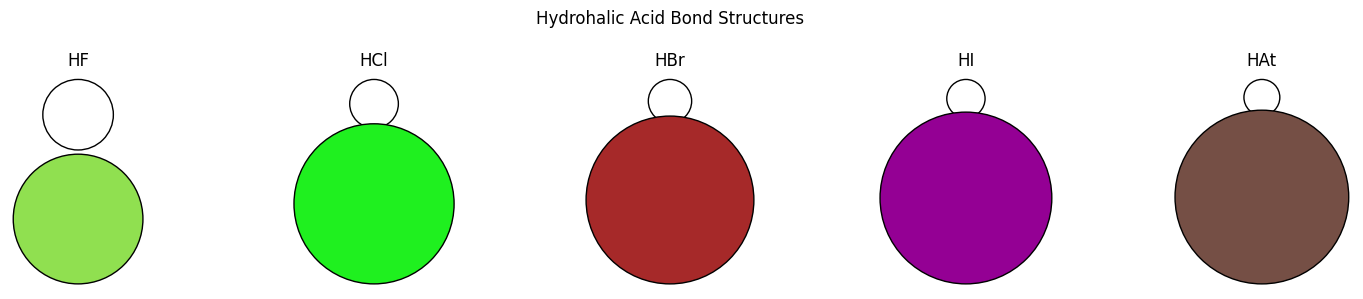

In [48]:
if ASE_AVAILABLE:
    molecules_for_plot = [
        ("HF", "F", 0.917),
        ("HCl", "Cl", 1.275),
        ("HBr", "Br", 1.414),
        ("HI", "I", 1.609),
        ("HAt", "At", 1.721),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))

    for ax, (name, halogen, bond_length) in zip(axes, molecules_for_plot):
        mol = make_hx(halogen, bond_length)
        plot_atoms(mol, ax, rotation=("90x,0y,0z"))
        ax.set_title(name)
        ax.axis("off")

    plt.suptitle("Hydrohalic Acid Bond Structures")
    plt.tight_layout()
    plt.show()
else:
    print("ASE is not available.")

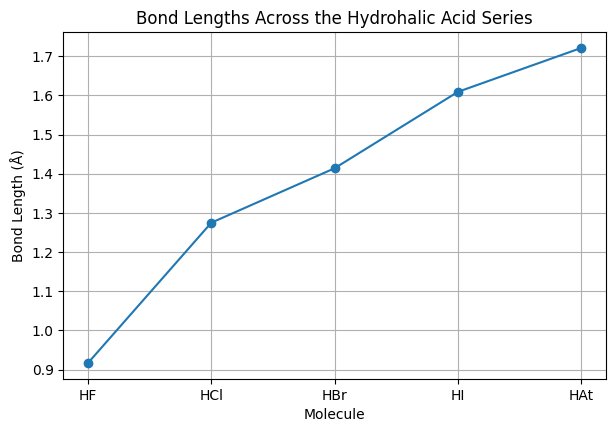

In [49]:
plt.figure(figsize=(7, 4.5))
plt.plot(df["Molecule"], df["BondLength_A"], marker="o")
plt.xlabel("Molecule")
plt.ylabel("Bond Length (Å)")
plt.title("Bond Lengths Across the Hydrohalic Acid Series")
plt.grid(True)
plt.show()

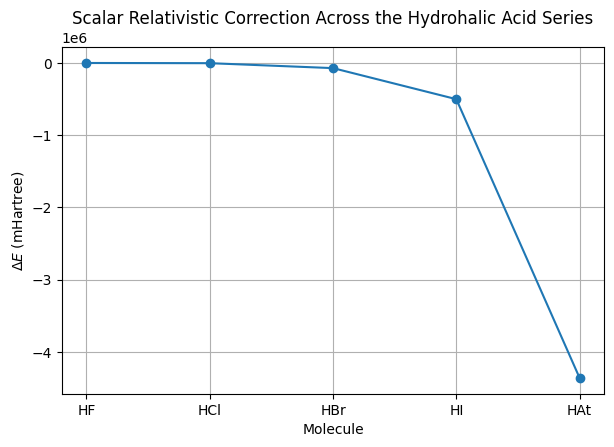

In [50]:
plt.figure(figsize=(7, 4.5))
plt.plot(df["Molecule"], df["DeltaE_mHa"], marker="o")
plt.xlabel("Molecule")
plt.ylabel(r"$\Delta E$ (mHartree)")
plt.title("Scalar Relativistic Correction Across the Hydrohalic Acid Series")
plt.grid(True)
plt.show()

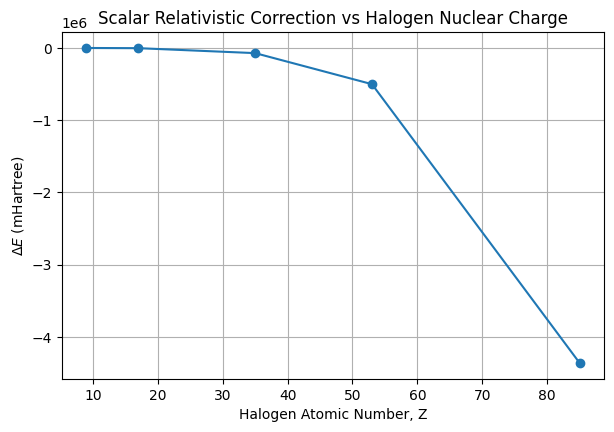

In [51]:
plt.figure(figsize=(7, 4.5))
plt.plot(df["Halogen_Z"], df["DeltaE_mHa"], marker="o")
plt.xlabel("Halogen Atomic Number, Z")
plt.ylabel(r"$\Delta E$ (mHartree)")
plt.title("Scalar Relativistic Correction vs Halogen Nuclear Charge")
plt.grid(True)
plt.show()

In [52]:
for name, info in systems.items():
    print(name, build_geometry(info["halogen_symbol"], info["bond_length"]))

HF H 0.000000 0.000000 0.000000; F 0.000000 0.000000 0.917000
HCl H 0.000000 0.000000 0.000000; Cl 0.000000 0.000000 1.275000
HBr H 0.000000 0.000000 0.000000; Br 0.000000 0.000000 1.414000
HI H 0.000000 0.000000 0.000000; I 0.000000 0.000000 1.609000
HAt H 0.000000 0.000000 0.000000; At 0.000000 0.000000 1.721000


### **Interpretation of Results: Scalar Relativistic Effects**

The results show a clear and systematic increase in the magnitude of the scalar relativistic correction across the hydrohalic acid series (HF → HAt).

---

#### Trend with Increasing Nuclear Charge

The relativistic correction $$( \Delta E = E_{\text{ZORA}} - E_{\text{NR}} )$$ becomes increasingly negative as the halogen atomic number increases:

* HF: very small correction
* HCl: small correction
* HBr: moderate correction
* HI: large correction
* HAt: extremely large correction

This trend reflects the increasing importance of relativistic effects for heavier atoms.

---

#### Physical Origin of the Trend

As nuclear charge increases:

* the Coulomb attraction between the nucleus and electrons becomes stronger
* electrons are drawn closer to the nucleus
* electron velocities increase, approaching a significant fraction of the speed of light

Under these conditions, the nonrelativistic kinetic energy operator becomes inaccurate, and relativistic corrections become necessary.

The ZORA correction accounts for this by modifying the kinetic energy through a position-dependent factor involving the effective potential.

---

#### Interpretation of the Plots

The plots show:

* a monotonic increase in the magnitude of $$( \Delta E )$$ with atomic number
* a nonlinear trend, with much stronger effects for heavier halogens

This is consistent with the expectation that relativistic effects scale strongly with nuclear charge.

---

#### Behavior of Astatine (HAt)

The correction for HAt is significantly larger than the other molecules. This is expected because:

* astatine has a very large nuclear charge
* relativistic effects are strongest for heavy elements

However, the result should be interpreted with caution because:

* fitted atomic density data (BFit) is not available for astatine
* only the nuclear contribution to the effective potential was used

As a result, the HAt value is **qualitatively correct** (very large relativistic effect) but less reliable quantitatively.

This highlights a limitation of the promolecular approximation when applied to very heavy elements. The lack of fitted atomic data for astatine means the effective potential is less accurate, which can affect the reliability of the relativistic correction.

---

#### Overall Conclusion

The results confirm that scalar relativistic effects:

* are negligible for light elements
* become increasingly important for heavier atoms
* significantly stabilize the electronic energy

This demonstrates that relativistic corrections are essential for accurately describing systems containing heavy elements.
